In [1]:
# impoting libraries 
import pandas as pd
import matplotlib.pyplot as plt 
from datasets import load_dataset
import ast

# loading dataset 
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# data cleanup 
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [ ]:
df_DA = df[df['job_title_short']=='Data Analyst']
df_exploded = df_DA.explode('job_skills')
top_10 = df_exploded['job_skills'].value_counts().sort_values(ascending=False).head(10).index.to_list()
df_grouped = df_exploded.groupby('job_skills').agg(skill_count = ('job_skills','size'),median_salary = ('salary_year_avg','median'))

In [87]:
df_grouped_top_skills = df_grouped.sort_values(by='skill_count', ascending=False).head(10)

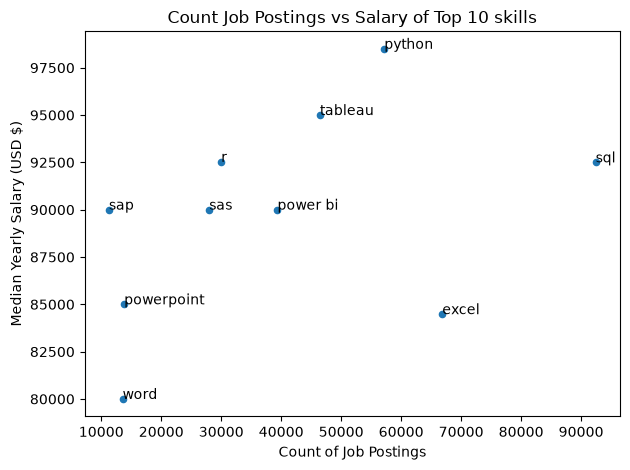

In [97]:
df_grouped_top_skills.plot(kind='scatter', x= 'skill_count', y= 'median_salary' )
plt.title('Count Job Postings vs Salary of Top 10 skills')
plt.ylabel('Median Yearly Salary (USD $)')
plt.xlabel('Count of Job Postings')
for i,txt in enumerate(df_grouped_top_skills.index):
    plt.text(x=df_grouped_top_skills['skill_count'].iloc[i], y=df_grouped_top_skills['median_salary'].iloc[i],s= txt)
plt.tight_layout()